In [2]:
%pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [7]:

df = pd.read_csv("Telco_Customer_Churn.csv")
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [8]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

# Imputing Missing Values in Total Charges

In [13]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")

df["TotalCharges"] = df["TotalCharges"].astype("float")

In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [16]:
df.isnull().sum().sum()

np.int64(0)

In [17]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [19]:
df["customerID"].duplicated().sum()

np.int64(0)

In [22]:
def conv(value):
    if value == 1:
        return "yes"
    else:
        return "no"

df['SeniorCitizen'] = df["SeniorCitizen"].apply(conv)

Mapping Senior Citizen Values to Yes/No

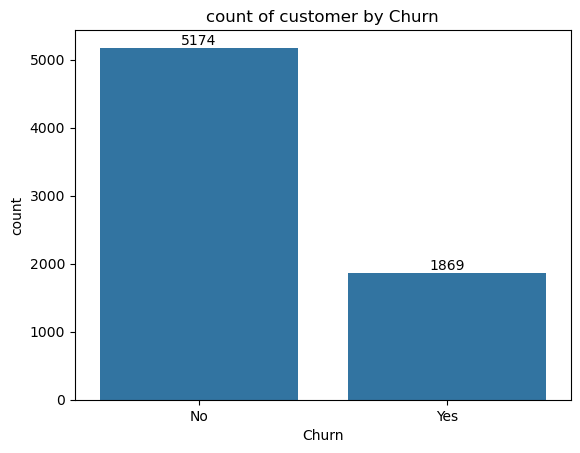

In [36]:
ax = sns.countplot(x = 'Churn' , data = df)

ax.bar_label(ax.containers[0])
plt.title("count of customer by Churn")
plt.show()

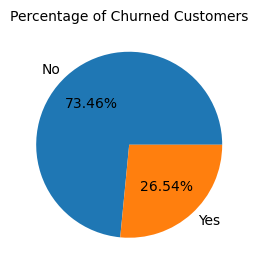

In [47]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn' : "count"})
plt.pie(gb['Churn'], labels = gb.index, autopct = "%1.2f%%")
plt.title("Percentage of Churned Customers" , fontsize = 10)
plt.show()

# Analyzing Our 26.54% Customer Churn: Key Drivers & Insights.

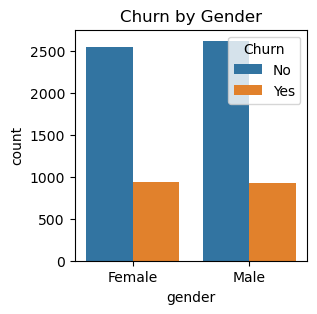

In [48]:
plt.figure(figsize = (3,3,))
sns.countplot(x = "gender", data = df , hue = "Churn")
plt.title("Churn by Gender")
plt.show()

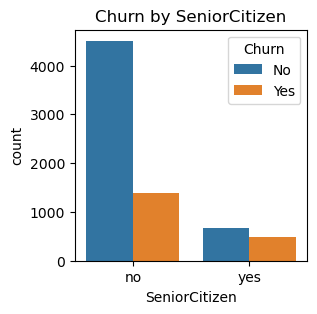

In [49]:
plt.figure(figsize = (3,3,))
sns.countplot(x = "SeniorCitizen", data = df , hue = "Churn")
plt.title("Churn by SeniorCitizen")
plt.show()

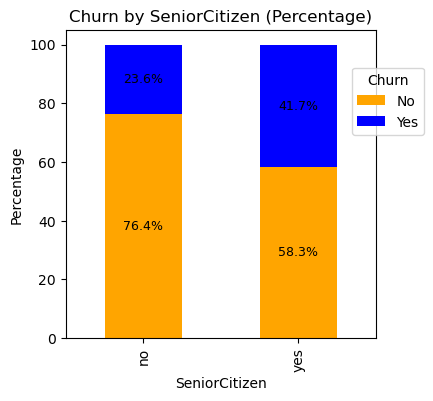

In [62]:
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Crosstab with percentages
ct = pd.crosstab(df['SeniorCitizen'], df['Churn'], normalize='index') * 100

# Step 2: Plot stacked bar chart with custom colors
ax = ct.plot(kind='bar', stacked=True, figsize=(4,4),
             color=['orange','blue'])   # Churn=No → orange, Churn=Yes → blue

# Step 3: Add percentage labels
for p in ax.patches:
    width = p.get_width()
    height = p.get_height()
    x, y = p.get_xy()
    if height > 0:
        ax.text(x + width/2, y + height/2, f'{height:.1f}%', 
                ha='center', va='center', fontsize=9, color='black')

plt.title("Churn by SeniorCitizen (Percentage)")
plt.ylabel("Percentage")
plt.xlabel("SeniorCitizen")
plt.legend(title="Churn",bbox_to_anchor = (0.9,0.9))  # customize Legend Locatiom 
plt.show()


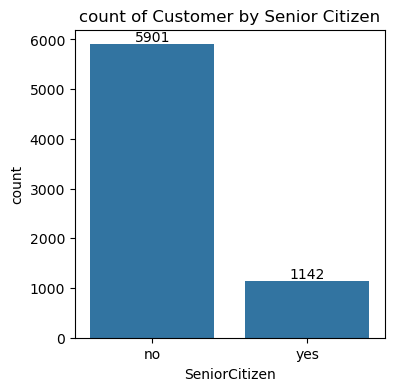

In [63]:
plt.figure(figsize = (4,4))
ax =sns.countplot(x = "SeniorCitizen", data = df )
ax.bar_label(ax.containers[0])
plt.title("count of Customer by Senior Citizen")
plt.show()

# Disproportionate Churn Rate Among Senior Citizens

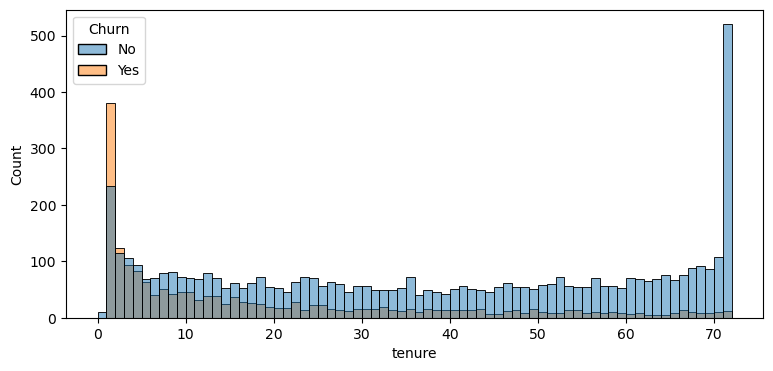

In [67]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure" , data = df , bins = 72, hue = "Churn")
plt.show()


## High Attrition in Early-Stage Customer

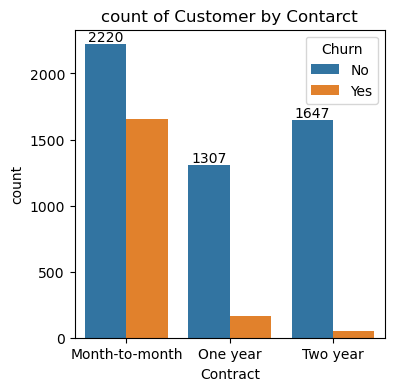

In [69]:
plt.figure(figsize = (4,4))
ax =sns.countplot(x = "Contract", data = df, hue = "Churn" )
ax.bar_label(ax.containers[0])
plt.title("count of Customer by Contarct")
plt.show()

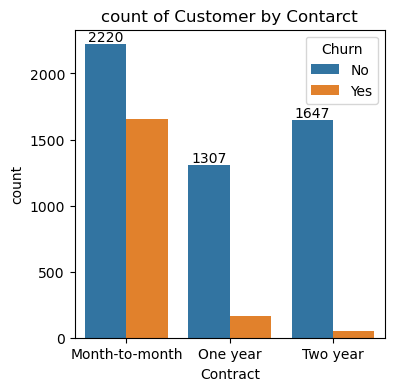

In [69]:
plt.figure(figsize = (4,4))
ax =sns.countplot(x = "Contract", data = df, hue = "Churn" )
ax.bar_label(ax.containers[0])
plt.title("count of Customer by Contarct")
plt.show()

## Higher Churn Risk Among Month‑to‑Month Contract Customers Compared to Long‑Term Contracts

In [70]:
df.columns.values

<StringArray>
[      'customerID',           'gender',    'SeniorCitizen',
          'Partner',       'Dependents',           'tenure',
     'PhoneService',    'MultipleLines',  'InternetService',
   'OnlineSecurity',     'OnlineBackup', 'DeviceProtection',
      'TechSupport',      'StreamingTV',  'StreamingMovies',
         'Contract', 'PaperlessBilling',    'PaymentMethod',
   'MonthlyCharges',     'TotalCharges',            'Churn']
Length: 21, dtype: str

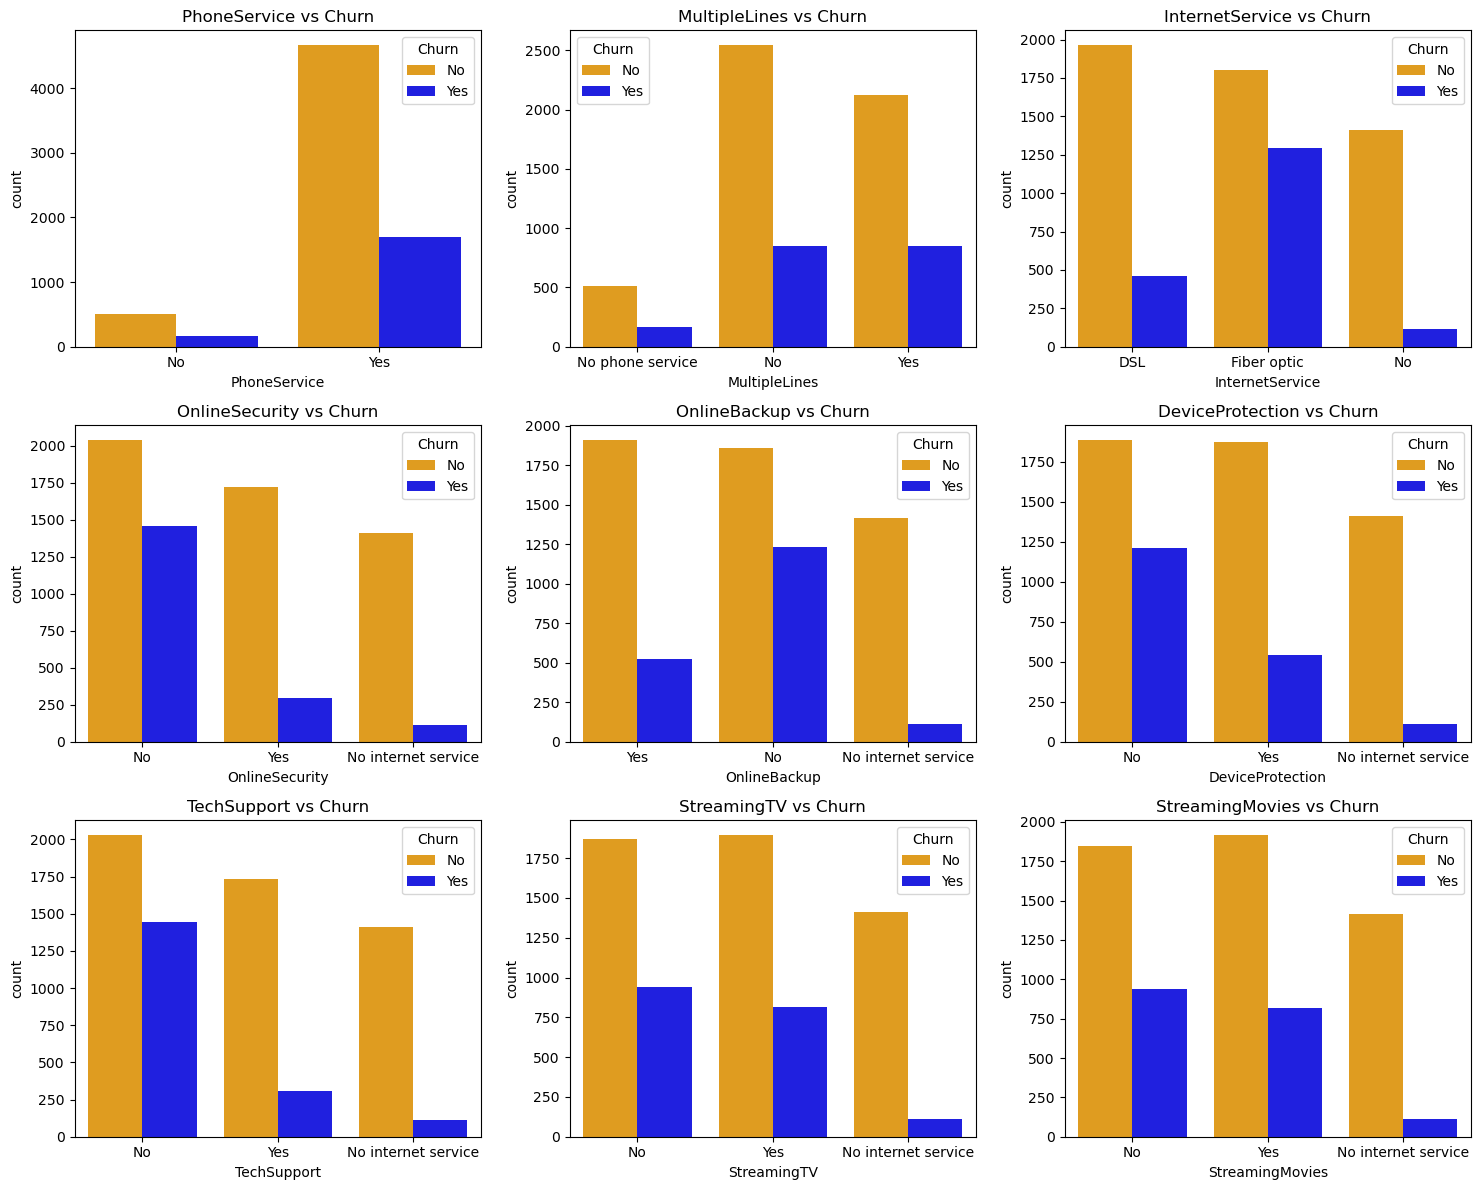

In [72]:

cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# Set up subplot grid
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(15,12))
axes = axes.flatten()

# Loop through each column and plot
for i, col in enumerate(cols):
    sns.countplot(x=col, data=df, hue="Churn", ax=axes[i], palette=["orange","blue"])
    axes[i].set_title(f"{col} vs Churn")
    axes[i].legend(title="Churn")

plt.tight_layout()
plt.show()


## Summary of Service Features and Churn Behavior

Customers subscribed to value‑added services such as OnlineSecurity, TechSupport, and DeviceProtection exhibit significantly lower churn, highlighting the retention benefits of these offerings.  
In contrast, basic services like PhoneService and MultipleLines show minimal impact on churn outcomes.  
The type of InternetService emerges as a critical factor, with fiber users demonstrating higher churn rates compared to DSL customers.  
Entertainment services, including StreamingTV and StreamingMovies, display a more balanced churn distribution, suggesting limited influence on customer retention.


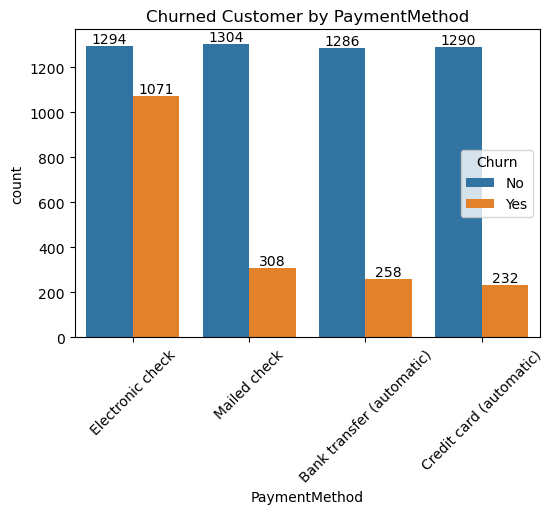

In [77]:
plt.figure(figsize = (6,4))
ax =sns.countplot(x = "PaymentMethod", data = df, hue = "Churn" )
ax.bar_label(ax.containers[0])
ax.bar_label(ax.containers[1])
plt.title("Churned Customer by PaymentMethod")
plt.xticks(rotation = 45)
plt.show()

# Customers utilizing Electronic Check as their payment method demonstrate a significantly higher likelihood of churn compared to those using alternative payment options.